In [1]:
# Install necessary libraries
!pip install pandas matplotlib seaborn scikit-learn
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Read the CSV file
df = pd.read_csv('hyderabad_hospital_resources.csv')

# Display first 5 rows
df.head()

Saving hyderabad_hospital_resources.csv to hyderabad_hospital_resources (1).csv


,Hospital_Name,Location,Specialty,Total_Beds,Available_Beds,ICU_Beds,Doctors,Nurses,Ventilators,Ambulances,Hospital_Rating,Total_Reviews,Contact_Number
0,Rainbow Children's Hospital,LB Nagar,Pulmonology,497,165,109,119,529,12,15,4.0,4264,80065547
1,Basavatarakam Indo American Cancer Hospital,Madhapur,Cardiology,1013,409,139,407,460,68,6,4.5,3935,1799318364
2,Rainbow Children's Hospital,LB Nagar,General Medicine,170,27,89,62,82,19,15,4.7,2398,5639753296
3,AIG Hospitals,Secunderabad,Orthopedics,793,130,26,301,397,43,15,3.6,2065,9766709835
4,AIG Hospitals,Kukatpally,Pediatrics,408,52,39,68,893,95,20,3.8,4737,6126502233


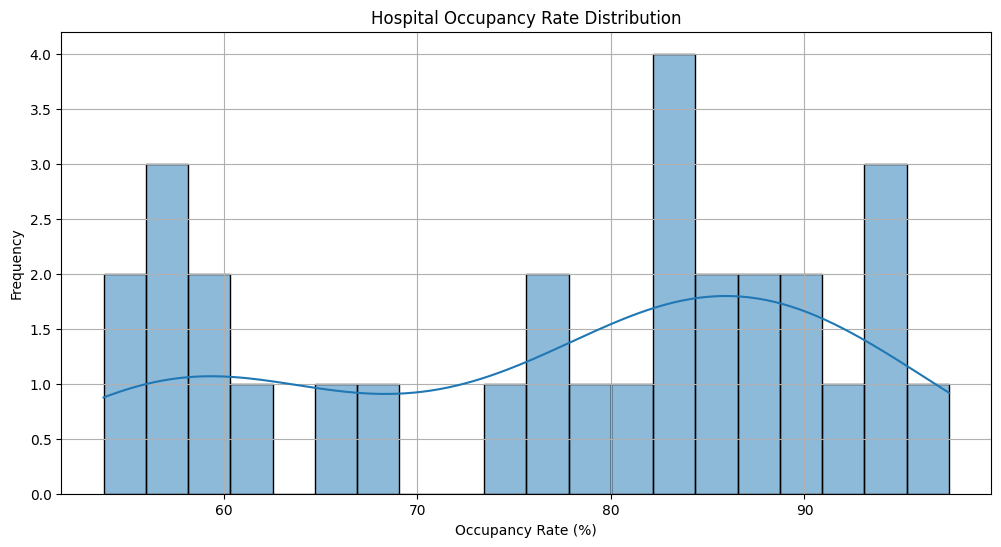

In [7]:
# Create Occupied_Beds column first
df['Occupied_Beds'] = df['Total_Beds'] - df['Available_Beds']

# Create occupancy rate
df['occupancy_rate'] = (df['Occupied_Beds'] / df['Total_Beds']) * 100

# Plot occupancy rate
plt.figure(figsize=(12,6))
sns.histplot(df['occupancy_rate'], bins=20, kde=True)
plt.title("Hospital Occupancy Rate Distribution")
plt.xlabel("Occupancy Rate (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

MAE: 2.696227255123367
R2 Score: 0.9820180365640905


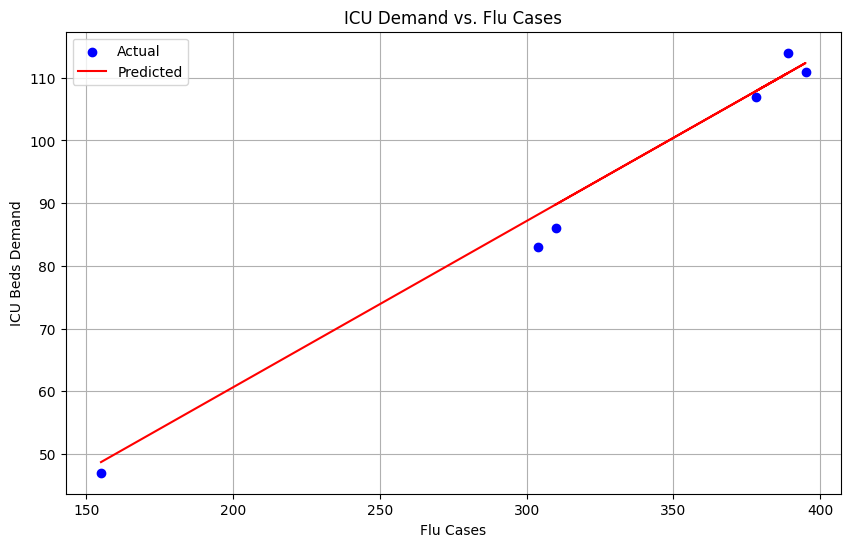

In [10]:
# Random flu cases
df['Flu_Cases'] = np.random.randint(50, 500, size=len(df))

# ICU Occupied Beds
df['ICU_Occupied_Beds'] = (
    df['Flu_Cases'] * 0.25 +
    np.random.randint(5, 20, size=len(df))
).astype(int)

# Check for missing values and drop rows with NaN in relevant columns
df = df.dropna(subset=['Flu_Cases', 'ICU_Occupied_Beds'])

# Simple regression model
X = df[['Flu_Cases']] # Independent variable
y = df['ICU_Occupied_Beds'] # Dependent variable

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

#Plot prediction
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel("Flu Cases")
plt.ylabel("ICU Beds Demand")
plt.title("ICU Demand vs. Flu Cases")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Staff-to-bed ratio
df['staff_to_bed_ratio'] = (df['Doctors'] + df['Nurses']) / df['Total_Beds']

# Flag hospitals needing staffing improvement
df['staffing_flag'] = np.where(
    (df['occupancy_rate'] > 85) & (df['staff_to_bed_ratio'] < 0.5),
    'Needs Improvement',
    'OK'
)

# Show flagged hospitals
df[df['staffing_flag'] == 'Needs Improvement'][
    ['Hospital_Name', 'occupancy_rate', 'staff_to_bed_ratio', 'staffing_flag']
]

,Hospital_Name,occupancy_rate,staff_to_bed_ratio,staffing_flag


In [20]:
import pandas as pd
import numpy as np
from google.colab import files

# Ensure 'Flu_Cases' and 'ICU_Occupied_Beds' columns exist for prediction
# This makes the cell robust against scenarios where df might have been reloaded.
if 'Flu_Cases' not in df.columns:
    df['Flu_Cases'] = np.random.randint(50, 500, size=len(df))
if 'ICU_Occupied_Beds' not in df.columns:
    df['ICU_Occupied_Beds'] = (
        df['Flu_Cases'] * 0.25 +
        np.random.randint(5, 20, size=len(df))
    ).astype(int)

# Ensure other necessary columns for the output file exist
if 'Occupied_Beds' not in df.columns:
    df['Occupied_Beds'] = df['Total_Beds'] - df['Available_Beds']

if 'occupancy_rate' not in df.columns:
    df['occupancy_rate'] = (df['Occupied_Beds'] / df['Total_Beds']) * 100

if 'staff_to_bed_ratio' not in df.columns:
    df['staff_to_bed_ratio'] = (df['Doctors'] + df['Nurses']) / df['Total_Beds']

if 'staffing_flag' not in df.columns:
    df['staffing_flag'] = np.where(
        (df['occupancy_rate'] > 85) & (df['staff_to_bed_ratio'] < 0.5),
        'Needs Improvement',
        'OK'
    )

# Ensure 'icu_predicted' is calculated as it's needed for the output file
# 'model' and 'Flu_Cases' are already available in the kernel from previous cells.
df['icu_predicted'] = model.predict(df[['Flu_Cases']])

# Define the columns to be included in the Excel summary.
# Using existing column names from the current DataFrame `df`.
output_columns = [
    'Hospital_Name', 'Flu_Cases', 'Occupied_Beds', 'Total_Beds', 'Doctors',
    'Nurses', 'occupancy_rate', 'staff_to_bed_ratio', 'staffing_flag',
    'ICU_Occupied_Beds', 'icu_predicted'
]

# Save the DataFrame to an Excel file
df[output_columns].to_excel("hospital_resource_summary.xlsx", index=False)

print("✅ Excel file 'hospital_resource_summary.xlsx' has been created.")

# Now, download the created file
files.download("hospital_resource_summary.xlsx")

✅ Excel file 'hospital_resource_summary.xlsx' has been created.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:


import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("hyderabad_hospital_resources.csv")


# Occupancy Rate
df['Occupied_Beds'] = df['Total_Beds'] - df['Available_Beds']

df['Occupancy_Rate'] = (
    df['Occupied_Beds'] / df['Total_Beds']
) * 100

# Staff-to-Bed Ratio
df['Staff_to_Bed_Ratio'] = (
    (df['Doctors'] + df['Nurses']) / df['Total_Beds']
)



# Random flu cases
df['Flu_Cases'] = np.random.randint(50, 500, size=len(df))

# ICU Occupied Beds
df['ICU_Occupied_Beds'] = (
    df['Flu_Cases'] * 0.25 +
    np.random.randint(5, 20, size=len(df))
).astype(int)



X = df[['Flu_Cases']]
y = df['ICU_Occupied_Beds']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train AI Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Accuracy")
print("MAE:", round(mae, 2))
print("R2 Score:", round(r2, 2))



# Hospital Score Formula
df['Hospital_Score'] = (
    (df['Available_Beds'] * 0.30) +
    (df['Doctors'] * 0.25) +
    (df['Hospital_Rating'] * 20) +
    (df['Staff_to_Bed_Ratio'] * 100) -
    (df['Occupancy_Rate'] * 0.20)
)

# Best Hospital
best_hospital = df.sort_values(
    by='Hospital_Score',
    ascending=False
).head(1)


print("\n==============================")
print(" BEST HOSPITAL SUGGESTION ")
print("==============================")

print(best_hospital[[
    'Hospital_Name',
    'Location',
    'Available_Beds',
    'Doctors',
    'Hospital_Rating',
    'Hospital_Score'
]])

Model Accuracy
MAE: 3.62
R2 Score: 0.99

 BEST HOSPITAL SUGGESTION 
        Hospital_Name    Location  Available_Beds  Doctors  Hospital_Rating  \
27  Yashoda Hospitals  Somajiguda              46      211              4.4   

    Hospital_Score  
27      650.885079  
